# 🔢 MNIST Digit Classification with Deep Learning

## Project Overview
This notebook demonstrates a complete machine learning pipeline for **handwritten digit classification** using the MNIST dataset. We explore two neural network architectures:

1. **Baseline Dense Neural Network** - A simple fully-connected architecture
2. **Convolutional Neural Network (CNN)** - A more sophisticated model with data augmentation

## Dataset
The **MNIST dataset** consists of 70,000 grayscale images of handwritten digits (0-9):
- **Training set**: 60,000 images (28×28 pixels)
- **Test set**: 10,000 images (28×28 pixels)

## Workflow
1. **Data Loading & Preprocessing** - Load MNIST, normalize pixel values
2. **Exploratory Data Analysis (EDA)** - Check data quality and distribution
3. **Baseline Model** - Train a Dense NN for baseline performance
4. **Data Augmentation** - Apply image transformations to improve generalization
5. **CNN Model** - Train an optimized CNN architecture
6. **Model Evaluation** - Compare performance metrics

---
**Author**: Osama Abd El Mohsen  
**Framework**: TensorFlow/Keras  
**Last Updated**: 2026

## 1. Import Libraries

Import all necessary dependencies for:
- **Data manipulation**: NumPy, Pandas
- **Visualization**: Matplotlib, Seaborn  
- **Deep Learning**: TensorFlow/Keras
- **Model persistence**: Joblib

In [3]:
from matplotlib import pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D , Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping , TensorBoard
from tensorflow.keras.optimizers import Adam

import joblib

from utils import show_img,classification_model_measurements

random_seed = 42

## 2. Data Loading & Preprocessing

Load the MNIST dataset directly from TensorFlow/Keras and apply normalization.

**Normalization**: Pixel values are scaled from [0, 255] to [0, 1] by dividing by 255. This:
- Speeds up gradient descent convergence
- Prevents large values from dominating the learning process
- Ensures consistent feature scales

In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scaling
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
print("X_train.shape  => ",X_train.shape)
print("X_test.shape  => ",X_test.shape)
print("y_train.shape  => ",y_train.shape)
print("y_test.shape  => ",y_test.shape)

X_train.shape  =>  (60000, 28, 28)
X_test.shape  =>  (10000, 28, 28)
y_train.shape  =>  (60000,)
y_test.shape  =>  (10000,)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values Check
Verify data integrity by checking for any null or NaN values in the dataset.

In [6]:
np.isnan(X_train).any(),np.isnan(X_test).any()

(np.False_, np.False_)

### 3.2 Class Distribution Analysis
Examine the distribution of digit classes to ensure a balanced dataset. An imbalanced dataset could bias the model towards majority classes.

In [7]:
values, counts = np.unique(y_train, return_counts=True)
print("Training set labels and counts:", values, counts)

values, counts = np.unique(y_test, return_counts=True)
values, counts
print("Test set labels and counts:", values, counts)

Training set labels and counts: [0 1 2 3 4 5 6 7 8 9] [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
Test set labels and counts: [0 1 2 3 4 5 6 7 8 9] [ 980 1135 1032 1010  982  892  958 1028  974 1009]


### 3.3 Data Visualization
Display sample images from the training set to understand the visual characteristics of handwritten digits.

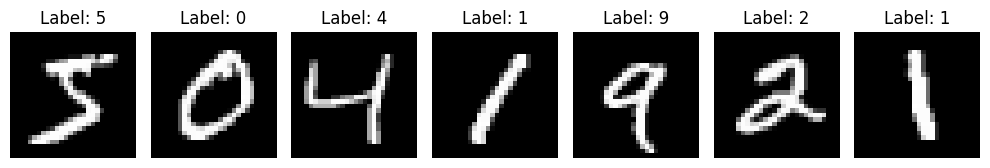

In [8]:
show_img(X_train,y_train,7)

## 4. Label Encoding

### 4.1 Original Labels
The target labels are integers from 0-9 representing each digit class.

In [9]:
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

### 4.2 One-Hot Encoding
Convert integer labels to one-hot encoded vectors for multi-class classification.

**Why One-Hot Encoding?**
- Neural networks with softmax output expect categorical target vectors
- Prevents the model from assuming ordinal relationships between classes (e.g., 9 is not "greater" than 1)
- Each digit becomes a 10-dimensional binary vector (e.g., digit 3 → [0,0,0,1,0,0,0,0,0,0])

In [10]:
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
y_test[0:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

## 5. Baseline Model: Dense Neural Network

Build a simple fully-connected (Dense) neural network as a baseline model.

### Architecture
- **Input**: Flatten 28×28 image → 784 features
- **Hidden Layer 1**: 128 neurons + ReLU + Dropout (30%)
- **Hidden Layer 2**: 64 neurons + ReLU + Dropout (30%)
- **Output**: 10 neurons + Softmax (probability distribution over 10 classes)

### Training Configuration
- **Loss**: Categorical Cross-Entropy (standard for multi-class classification)
- **Optimizer**: Adam (adaptive learning rate)
- **Early Stopping**: Monitor validation loss, restore best weights

In [11]:
early_stop  = EarlyStopping(monitor='val_loss', patience=3 ,restore_best_weights=True)

In [12]:
model = Sequential(
    [
        Flatten(input_shape=(28, 28 )),
        Dense(units = 128,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 64,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 10,activation = 'softmax'),
    ]
)

model.compile(
    loss = 'categorical_crossentropy' , 
    optimizer='Adam',
    metrics=['accuracy'] ,
)


d:\Programming\ai-practice\02 MINST Dataset\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8201 - loss: 0.5855 - val_accuracy: 0.9412 - val_loss: 0.2067
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9216 - loss: 0.2670 - val_accuracy: 0.9539 - val_loss: 0.1517
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9379 - loss: 0.2117 - val_accuracy: 0.9644 - val_loss: 0.1242
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9487 - loss: 0.1746 - val_accuracy: 0.9650 - val_loss: 0.1192
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9549 - loss: 0.1520 - val_accuracy: 0.9700 - val_loss: 0.1007
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9598 - loss: 0.1323 - val_accuracy: 0.9720 - val_loss: 0.0942
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9627 - loss: 0.1241 - val_accuracy: 0.9730 - val_loss: 0.0901
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9662 - loss: 0.1130 - val_accuracy: 0.

### 5.1 Model Evaluation (Baseline)
Evaluate the Dense NN performance on both training and test sets.

In [14]:
y_t_pred = model.predict(X_train)
y_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [15]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
y_train_labels = np.argmax(y_train, axis=1)
y_t_pred_labels = np.argmax(y_t_pred, axis=1)
classification_model_measurements(y_train_labels,y_t_pred_labels,y_test_labels,y_pred_labels)


************ MODEL EVALUATION METRICS ************

                  ACCURACY SCORE                  
--------------------------------------------------
Training  => 99.06%
Testing   => 97.81%

                 CONFUSION MATRIX                 
--------------------------------------------------
Training:
[[5896    0    8    0    0    1    8    1    5    4]
 [   0 6709    6    4    0    0    3    7   11    2]
 [   8    3 5904    9    1    0    1   10   19    3]
 [   2    0   25 6042    0   19    0    7   27    9]
 [   4    7    8    0 5745    0    9    3    5   61]
 [   9    1    4   15    0 5354   13    1   14   10]
 [  10    0    1    0    2    3 5897    0    5    0]
 [   3   12   14    4    3    0    0 6213    4   12]
 [   7    9    6    8    0    3    7    3 5804    4]
 [   4    3    0   16   10    4    0   26   11 5875]]

Testing:
[[ 971    0    0    1    0    1    3    1    3    0]
 [   0 1124    4    1    0    1    1    0    4    0]
 [   5    2 1007    1    0    0    2    6    

## 6. Data Augmentation

Data augmentation artificially expands the training dataset by applying random transformations to images. This helps:

- **Reduce overfitting** by exposing the model to more variations
- **Improve generalization** to unseen handwriting styles
- **Simulate real-world variations** in digit appearance

### Transformations Applied
| Transformation | Value | Purpose |
|----------------|-------|---------|
| Rotation | ±10° | Handle tilted digits |
| Zoom | ±10% | Handle size variations |
| Width Shift | ±10% | Handle horizontal positioning |
| Height Shift | ±10% | Handle vertical positioning |

### Reshape for CNN
Images must be reshaped from (28, 28) to (28, 28, 1) to include the channel dimension required by Conv2D layers.

In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1,28,28,1)

In [26]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,  
    zoom_range = 0.10,  
    width_shift_range=0.1, 
    height_shift_range=0.1
)

datagen.fit(X_train)

### 6.1 Visualize Augmented Images
Display samples of augmented images to verify the transformations are applied correctly.

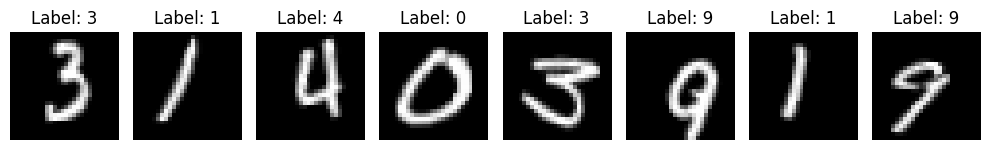

In [28]:
import matplotlib.pyplot as plt
import numpy as np

augmented_images, augmented_labels = next(
    datagen.flow(X_train, y_train, batch_size=8)
)
augmented_labels = [np.argmax(x) for x in augmented_labels]

show_img(augmented_images,augmented_labels,8)

## 7. Convolutional Neural Network (CNN)

CNNs are specifically designed for image data and outperform Dense networks by:


### Architecture
```
Block 1: Conv2D(32) → BatchNorm → Conv2D(32) → BatchNorm → MaxPool → Dropout(25%)
Block 2: Conv2D(64) → BatchNorm → Conv2D(64) → BatchNorm → MaxPool → Dropout(25%)
Classification: Flatten → Dense(128) → BatchNorm → Dropout(50%) → Softmax(10)
```

### Key Components
- **Conv2D**: Extract local features using 3×3 learnable filters
- **BatchNormalization**: Normalize activations for faster, more stable training  
- **MaxPooling2D**: Downsample spatial dimensions, retain important features
- **Dropout**: Regularization to prevent overfitting

In [29]:
early_stop  = EarlyStopping(monitor='val_loss', patience=3 ,restore_best_weights=True)

In [30]:
tensor_board = TensorBoard(histogram_freq = 1 , log_dir = "../logs/")

In [31]:
model = Sequential([
    
    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

d:\Programming\ai-practice\02 MINST Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks = [early_stop,tensor_board]
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.9061 - loss: 0.3018 - val_accuracy: 0.9884 - val_loss: 0.0365
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9681 - loss: 0.1056 - val_accuracy: 0.9924 - val_loss: 0.0233
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9749 - loss: 0.0825 - val_accuracy: 0.9916 - val_loss: 0.0273
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9784 - loss: 0.0703 - val_accuracy: 0.9926 - val_loss: 0.0230
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9813 - loss: 0.0632 - val_accuracy: 0.9933 - val_loss: 0.0194
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.9833 - loss: 0.0585 - val_accuracy: 0.9952 - val_loss: 0.0164
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9839 - loss: 0.0538 - val_accuracy: 0.9929 - val_loss: 0.0204
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9859 - loss: 0.0479 - 

In [34]:
y_t_pred = model.predict(X_train)
y_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


### 7.1 Model Evaluation
Evaluate the CNN model performance using accuracy, confusion matrix, and classification report.

In [43]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
y_train_labels = np.argmax(y_train, axis=1)
y_t_pred_labels = np.argmax(y_t_pred, axis=1)
classification_model_measurements(y_train_labels,y_t_pred_labels,y_test_labels,y_pred_labels)

************ MODEL EVALUATION METRICS ************

                  ACCURACY SCORE                  
--------------------------------------------------
Training  => 99.56%
Testing   => 99.58%

                 CONFUSION MATRIX                 
--------------------------------------------------
Training:
[[5919    1    0    0    0    0    2    0    1    0]
 [   0 6718    3    2    0    0    4   12    3    0]
 [   7    2 5929    5    0    1    1    9    3    1]
 [   0    0    3 6118    0    5    0    2    2    1]
 [   0    3    0    0 5804    0    2    4    0   29]
 [   2    0    0   14    0 5393   10    0    1    1]
 [   5    0    0    0    3    6 5902    0    2    0]
 [   0    9    8    1    1    0    0 6242    1    3]
 [   5    2    1    6    3    7    8    0 5810    9]
 [   6    2    0    5   11    9    0    9    9 5898]]

Testing:
[[ 980    0    0    0    0    0    0    0    0    0]
 [   0 1129    0    3    0    0    2    1    0    0]
 [   1    0 1027    1    0    0    1    2    0

In [ ]:
# joblib.dump(model, "../model/mnist_model.pkl")

['../model/mnist_model.pkl']

## 8. Model Export & Conclusion

### Summary
| Model | Architecture | Key Features | Expected Accuracy |
|-------|-------------|--------------|-------------------|
| **Baseline Dense NN** | Flatten → Dense(128) → Dense(64) → Softmax | Simple, fast training | ~97% |
| **CNN** | Conv2D blocks + Dense head | Spatial feature learning, data augmentation | ~99.5% |

### Key Takeaways
1. **Data preprocessing** (normalization, one-hot encoding) is essential for neural network training
2. **CNNs significantly outperform** Dense networks on image classification tasks
3. **Data augmentation** helps prevent overfitting and improves generalization
4. **Batch normalization and Dropout** are effective regularization techniques

---
**Next Steps**: The trained model is deployed via the Streamlit app in `app/app.py` for interactive digit prediction.